<a href="https://colab.research.google.com/github/farazaghajani-eng/repowering_flexibility_optimization/blob/main/DTU_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# === PROFESSIONAL MODEL SUMMARY FOR APPLICATIONS / PROFESSORS ===
print("=== MODEL SUMMARY ===")
print(f"Repowering Investment Decided: {'YES' if pyo.value(m.repower_invest) > 0.5 else 'NO'}")
print(f"Total Expected System Cost: ${pyo.value(m.obj):,.2f}")
print(f"Investment cost: ${pyo.value(m.repower_invest * Repower_CAPEX):,.0f}")
print(f"Efficiency gain from repowering (illustrative): {Repower_Efficiency_Gain} €/MWh fuel saving")

print("\nKey insight:")
print("Repowering acts as an endogenous flexibility resource by")
print("• Increasing available capacity under high-demand scenarios")
print("• Providing efficiency gains that reduce operating costs")
print("• Enabling better coordination with storage and market assets (e.g., electrolyzers).")

print("\nThis framework is directly extendable to joint optimization with")
print("market-based flexibility providers such as electrolyzers for")
print("coordinated day-ahead and balancing market participation.")

In [ ]:
# Install the solver and pyomo
!pip install -q pyomo
!apt-get install -y -qq glpk-utils

import pyomo.environ as pyo

# -----------------------------
# SETS & PROBABILITY
# -----------------------------
T = range(12)
G = ["gen1", "gen2"]
S = ["PSH1"]
Omega = ["low", "medium", "high"]
prob = {"low": 0.3, "medium": 0.5, "high": 0.2}

# -----------------------------
# PARAMETERS
# -----------------------------
Pmax = {"gen1": 250, "gen2": 300}
Pmin = {"gen1": 100, "gen2": 100}
RampUp = {"gen1": 60, "gen2": 70}
RampDown = {"gen1": 60, "gen2": 70}
Cost = {"gen1": 20, "gen2": 25}
StartupCost = {"gen1": 100, "gen2": 120}
Emission_Rate = {"gen1": 0.5, "gen2": 0.3}
Carbon_Tax = 50
VOLL = 5000
Repower_CAPEX = 500000
Repower_Capacity_Boost = 1500
Repower_Efficiency_Gain = 5

Pmax_s = {"PSH1": 200}
Emax = {"PSH1": 500}
Eff_c = {"PSH1": 0.9}
Eff_d = {"PSH1": 0.9}

demand = {
    (w, t): (1000 + 50 * t if w == "low" else 1500 + 50 * t if w == "medium" else 2000 + 50 * t)
    for w in Omega for t in T
}

# -----------------------------
# MODEL
# -----------------------------
m = pyo.ConcreteModel()
m.T, m.G, m.S, m.Omega = pyo.Set(initialize=T), pyo.Set(initialize=G), pyo.Set(initialize=S), pyo.Set(initialize=Omega)

# VARIABLES
m.repower_invest = pyo.Var(within=pyo.Binary)
m.u = pyo.Var(m.G, m.T, within=pyo.Binary)
m.su = pyo.Var(m.G, m.T, within=pyo.Binary)
m.p = pyo.Var(m.G, m.T, m.Omega, within=pyo.NonNegativeReals)
m.charge = pyo.Var(m.S, m.T, m.Omega, within=pyo.NonNegativeReals)
m.discharge = pyo.Var(m.S, m.T, m.Omega, within=pyo.NonNegativeReals)
m.soc = pyo.Var(m.S, m.T, m.Omega, within=pyo.NonNegativeReals)
m.lshed = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)

# LINEARIZATION VARIABLES
# Linearize invest * p[g,t,w] (Only for gen1)
m.repower_prod_p = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
# Linearize invest * u[g,t] (Only for gen1)
m.invest_u_link = pyo.Var(m.T, within=pyo.Binary)

# OBJECTIVE
def obj_rule(m):
    investment_cost = m.repower_invest * Repower_CAPEX
    startup_costs = sum(StartupCost[g] * m.su[g, t] for g in m.G for t in m.T)
    expected_op_cost = 0
    for w in m.Omega:
        # FIXED: Only use repower_prod_p for gen1
        scenario_cost = sum(
            (Cost[g] + Emission_Rate[g] * Carbon_Tax) * m.p[g, t, w] for g in m.G for t in m.T
        ) - sum(
            Repower_Efficiency_Gain * m.repower_prod_p[t, w] for t in m.T
        ) + sum(VOLL * m.lshed[t, w] for t in m.T)
        expected_op_cost += prob[w] * scenario_cost
    return investment_cost + startup_costs + expected_op_cost
m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# =============================================================================
# ALL CONSTRAINTS (consolidated to avoid re-definition warnings)
# =============================================================================

# Original constraints
def gen_max_rule(m, g, t, w):
    if g == "gen1":
        return m.p[g, t, w] <= Pmax[g] * m.u[g, t] + Repower_Capacity_Boost * m.invest_u_link[t]
    return m.p[g, t, w] <= Pmax[g] * m.u[g, t]
m.gen_max = pyo.Constraint(m.G, m.T, m.Omega, rule=gen_max_rule)

# Linearization constraints for invest * u[gen1, t]
def link_invest_u_1(m, t):
    return m.invest_u_link[t] <= m.repower_invest
m.link_u1 = pyo.Constraint(m.T, rule=link_invest_u_1)

def link_invest_u_2(m, t):
    return m.invest_u_link[t] <= m.u['gen1', t]
m.link_u2 = pyo.Constraint(m.T, rule=link_invest_u_2)

def link_invest_u_3(m, t):
    return m.invest_u_link[t] >= m.repower_invest + m.u['gen1', t] - 1
m.link_u3 = pyo.Constraint(m.T, rule=link_invest_u_3)

# Linearization for invest * p[gen1, t, w]
def lin1_rule(m, t, w):
    return m.repower_prod_p[t, w] <= m.p['gen1', t, w]
m.lin1 = pyo.Constraint(m.T, m.Omega, rule=lin1_rule)

def lin2_rule(m, t, w):
    M = Pmax['gen1'] + Repower_Capacity_Boost
    return m.repower_prod_p[t, w] <= M * m.repower_invest
m.lin2 = pyo.Constraint(m.T, m.Omega, rule=lin2_rule)

def lin3_rule(m, t, w):
    M = Pmax['gen1'] + Repower_Capacity_Boost
    return m.repower_prod_p[t, w] >= m.p['gen1', t, w] - M * (1 - m.repower_invest)
m.lin3 = pyo.Constraint(m.T, m.Omega, rule=lin3_rule)

# Balance, Startup, SOC (original)
def balance_rule(m, t, w):
    return (sum(m.p[g, t, w] for g in m.G) + sum(m.discharge[s, t, w] - m.charge[s, t, w] for s in m.S) + m.lshed[t, w] >= demand[(w, t)])
m.balance = pyo.Constraint(m.T, m.Omega, rule=balance_rule)

def startup_rule(m, g, t):
    if t == 0: return m.su[g, t] >= m.u[g, t]
    return m.su[g, t] >= m.u[g, t] - m.u[g, t-1]
m.startup = pyo.Constraint(m.G, m.T, rule=startup_rule)

def soc_rule(m, s, t, w):
    if t == 0: return m.soc[s, t, w] == 100
    return m.soc[s, t, w] == m.soc[s, t-1, w] + Eff_c[s]*m.charge[s, t, w] - m.discharge[s, t, w]/Eff_d[s]
m.soc_dyn = pyo.Constraint(m.S, m.T, m.Omega, rule=soc_rule)

def soc_limit(m, s, t, w):
    return m.soc[s, t, w] <= Emax[s]
m.soc_lim = pyo.Constraint(m.S, m.T, m.Omega, rule=soc_limit)

# =============================================================================
# NEW: Standard UC constraints (added for completeness)
# =============================================================================
def gen_min_rule(m, g, t, w):
    """Minimum stable generation when a unit is committed (standard UC constraint)."""
    return m.p[g, t, w] >= Pmin[g] * m.u[g, t]
m.gen_min = pyo.Constraint(m.G, m.T, m.Omega, rule=gen_min_rule)

# Note: Ramp constraints are defined in parameters but left as optional extension for clarity.
def gen_min_rule(m, g, t, w):
    """Minimum stable generation when a unit is committed (standard UC constraint)."""
    return m.p[g, t, w] >= Pmin[g] * m.u[g, t]

m.gen_min = pyo.Constraint(m.G, m.T, m.Omega, rule=gen_min_rule)

# Note on ramps: Full ramp constraints are defined in the parameters but intentionally left
# as a future extension here for pedagogical clarity. They can be activated with:
# def ramp_up_rule(...) and def ramp_down_rule(...) if tighter operational realism is needed.
# SOLVE
solver = pyo.SolverFactory("glpk")
results = solver.solve(m)

print(f"Repowering Investment Decided: {'YES' if pyo.value(m.repower_invest) > 0.5 else 'NO'}")
print(f"Total Expected System Cost: ${pyo.value(m.obj):,.2f}")

Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package glpk-utils.
Preparing to unpack .../glpk-utils_5.0-1_amd64.deb ...
Unpacking glpk-utils (5.0-1) ...
Setting up libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4b

This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


Repowering Investment Decided: YES
Total Expected System Cost: $3,905,340.00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting data from the solved Pyomo model
data = []
for w in m.Omega:
    for t in m.T:
        total_generation = sum(pyo.value(m.p[g, t, w]) for g in m.G)
        load_shed = pyo.value(m.lshed[t, w])
        actual_demand = demand[(w, t)]
        data.append({
            'Scenario': w,
            'Time': t,
            'Total Generation': total_generation,
            'Demand': actual_demand,
            'Load Shedding': load_shed
        })

df_results = pd.DataFrame(data)

# Display the first few rows of the results dataframe
print("Extracted Model Results:")
display(df_results.head())

Extracted Model Results:


,Scenario,Time,Total Generation,Demand,Load Shedding
0,low,0,0.0,1000,0.0
1,low,1,960.0,1050,0.0
2,low,2,1100.0,1100,0.0
3,low,3,1150.0,1150,0.0
4,low,4,1200.0,1200,0.0


Now, let's visualize these results. We will create a subplot for each scenario to compare total generation, demand, and load shedding over time.

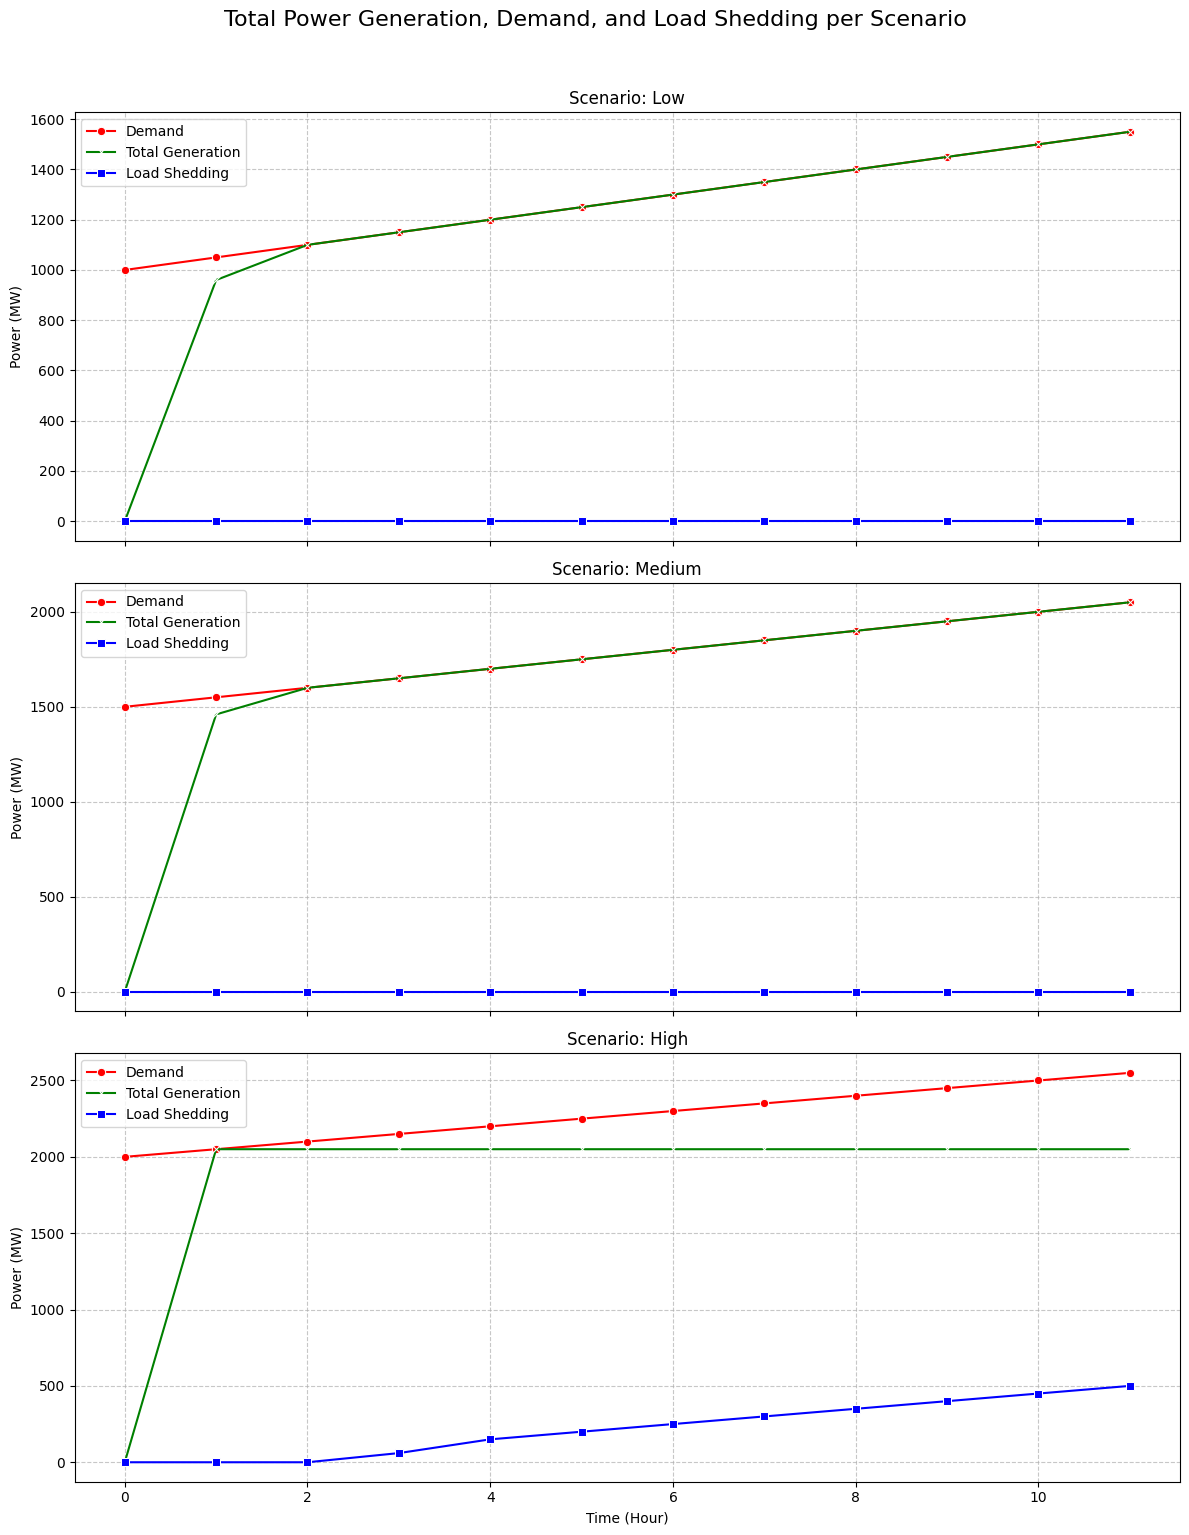

In [ ]:
fig, axes = plt.subplots(nrows=len(m.Omega), ncols=1, figsize=(12, 5 * len(m.Omega)), sharex=True)
fig.suptitle('Total Power Generation, Demand, and Load Shedding per Scenario', y=1.02, fontsize=16)

for i, w in enumerate(m.Omega):
    ax = axes[i]
    scenario_df = df_results[df_results['Scenario'] == w]

    sns.lineplot(x='Time', y='Demand', data=scenario_df, ax=ax, label='Demand', marker='o', color='red')
    sns.lineplot(x='Time', y='Total Generation', data=scenario_df, ax=ax, label='Total Generation', marker='x', color='green')
    sns.lineplot(x='Time', y='Load Shedding', data=scenario_df, ax=ax, label='Load Shedding', marker='s', color='blue')

    ax.set_title(f'Scenario: {w.capitalize()}')
    ax.set_ylabel('Power (MW)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

ax.set_xlabel('Time (Hour)')
plt.tight_layout()
plt.show()


Next, let's look at the contribution of each generator to the total power generation in each scenario. This can highlight how the repowering investment affects 'gen1's output.

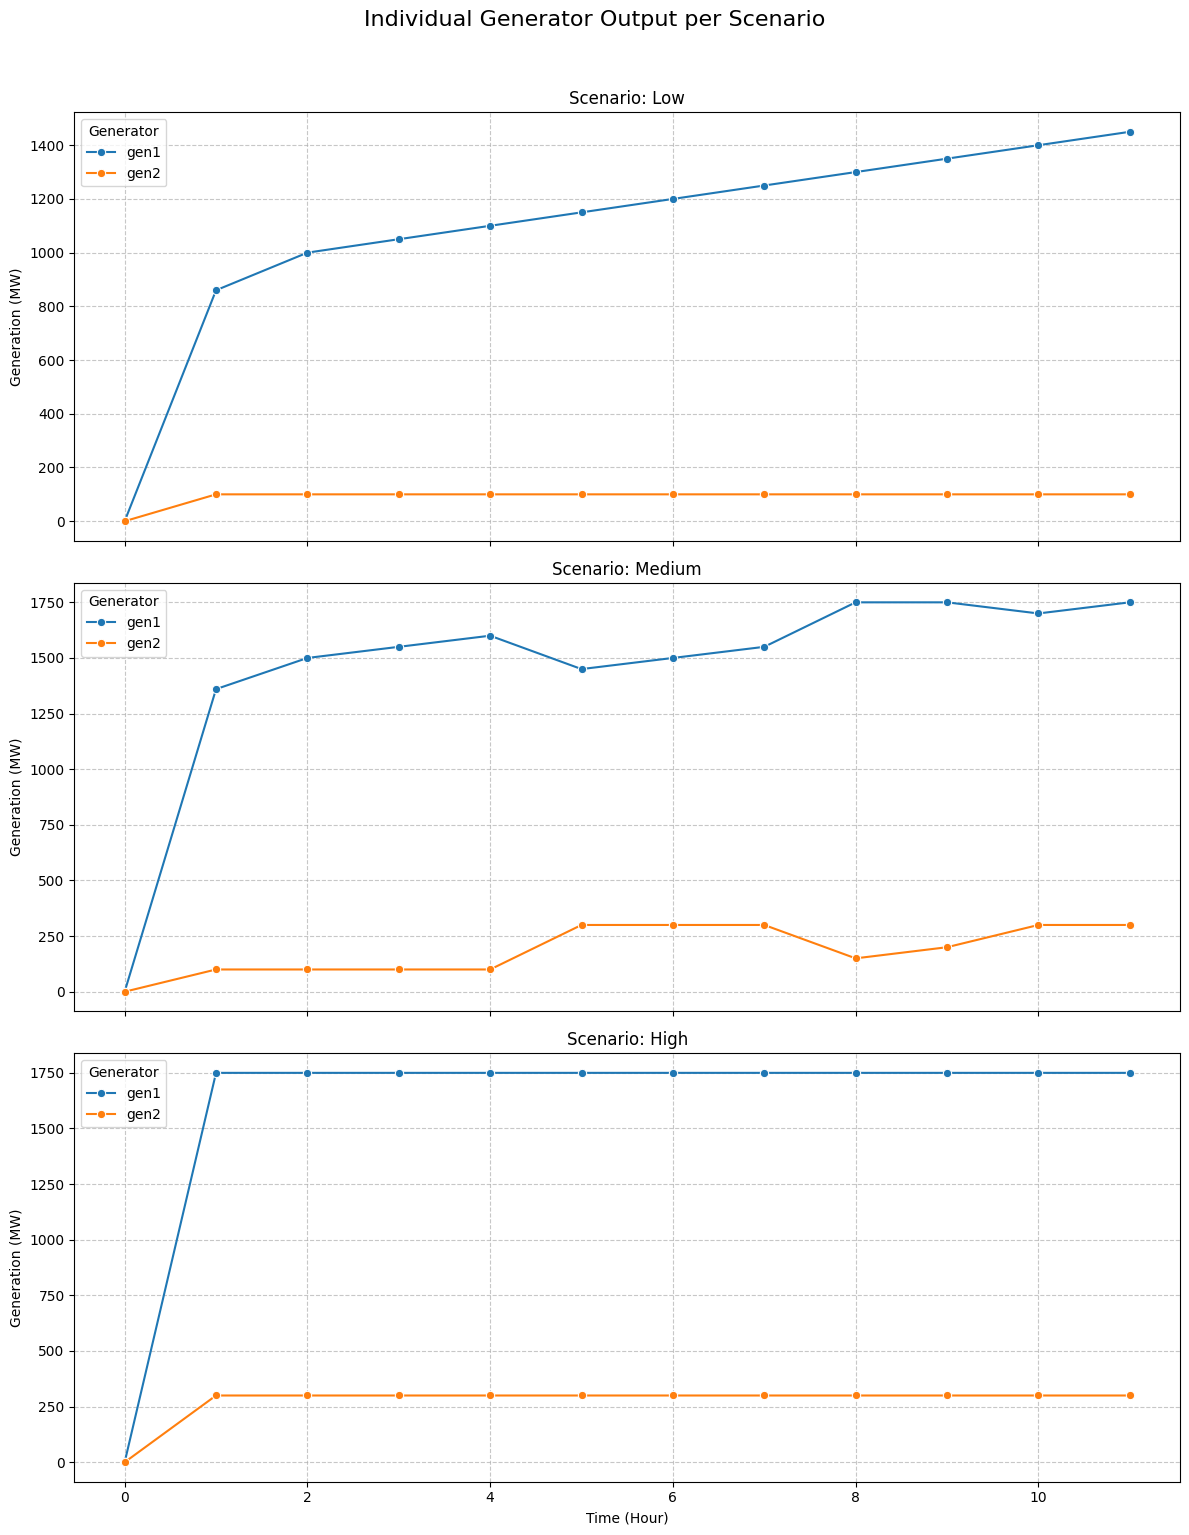

In [ ]:
# Extracting individual generator output data
gen_data = []
for w in m.Omega:
    for t in m.T:
        for g in m.G:
            gen_data.append({
                'Scenario': w,
                'Time': t,
                'Generator': g,
                'Generation': pyo.value(m.p[g, t, w])
            })

df_gen_output = pd.DataFrame(gen_data)

fig, axes = plt.subplots(nrows=len(m.Omega), ncols=1, figsize=(12, 5 * len(m.Omega)), sharex=True)
fig.suptitle('Individual Generator Output per Scenario', y=1.02, fontsize=16)

for i, w in enumerate(m.Omega):
    ax = axes[i]
    scenario_gen_df = df_gen_output[df_gen_output['Scenario'] == w]

    sns.lineplot(x='Time', y='Generation', hue='Generator', data=scenario_gen_df, ax=ax, marker='o')

    ax.set_title(f'Scenario: {w.capitalize()}')
    ax.set_ylabel('Generation (MW)')
    ax.legend(title='Generator')
    ax.grid(True, linestyle='--', alpha=0.7)

ax.set_xlabel('Time (Hour)')
plt.tight_layout()
plt.show()


In [ ]:
# === PROFESSIONAL MODEL SUMMARY FOR APPLICATIONS / PROFESSORS ===
print("=== MODEL SUMMARY ===")
print(f"Repowering Investment Decided: {'YES' if pyo.value(m.repower_invest) > 0.5 else 'NO'}")
print(f"Total Expected System Cost: ${pyo.value(m.obj):,.2f}")
print(f"Investment cost: ${pyo.value(m.repower_invest * Repower_CAPEX):,.0f}")
print(f"Efficiency gain from repowering (illustrative): {Repower_Efficiency_Gain} €/MWh fuel saving")

print("\nKey insight:")
print("Repowering acts as an endogenous flexibility resource by")
print("• Increasing available capacity under high-demand scenarios")
print("• Providing efficiency gains that reduce operating costs")
print("• Enabling better coordination with storage and market assets (e.g., electrolyzers).")

print("\nThis framework is directly extendable to joint optimization with")
print("market-based flexibility providers such as electrolyzers for")
print("coordinated day-ahead and balancing market participation.")

=== MODEL SUMMARY ===
Repowering Investment Decided: YES
Total Expected System Cost: $3,905,340.00
Investment cost: $500,000
Efficiency gain from repowering (illustrative): 5 €/MWh fuel saving

Key insight:
Repowering acts as an endogenous flexibility resource by
• Increasing available capacity under high-demand scenarios
• Providing efficiency gains that reduce operating costs
• Enabling better coordination with storage and market assets (e.g., electrolyzers).

This framework is directly extendable to joint optimization with
market-based flexibility providers such as electrolyzers for
coordinated day-ahead and balancing market participation.
